In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#loading/cleaning the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

In [3]:
# Load data, converting '?' strings directly into NaN values
df = pd.read_csv(url, names=column_names, na_values="?")

In [4]:
# Clean missing values by replacing them with the column median
df = df.fillna(df.median())

In [5]:
# Convert to Binary Classification: 0 = No Disease, 1 = Heart Disease Present
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

print(" Data Inspection ")
print(f"Dataset Shape: {df.shape}")
print(df.head(), "\n")

### Data Inspection ###
Dataset Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0   



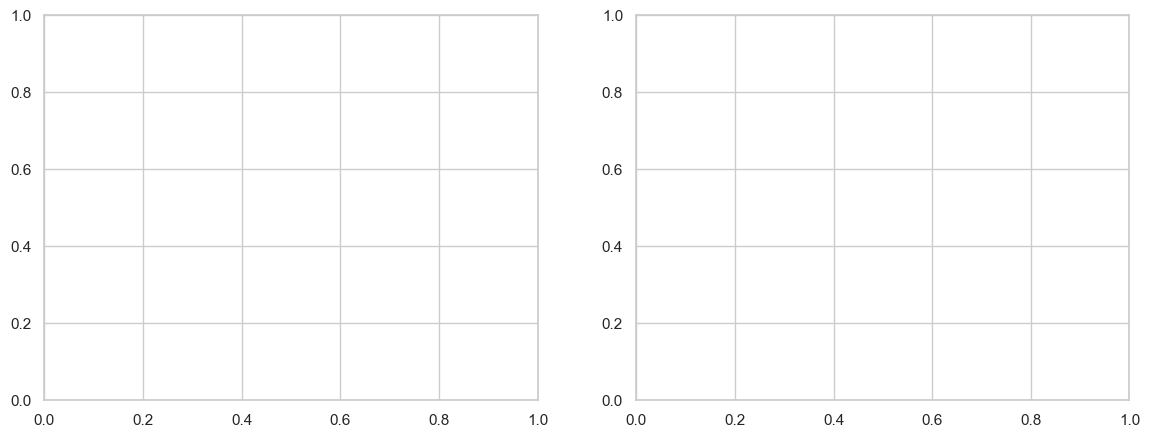

In [6]:
#EDA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [7]:
# Target Distribution Plot
sns.countplot(
    x="target", data=df, ax=axes[0], palette="Set2", hue="target", legend=False
)
axes[0].set_title("Distribution of Heart Disease")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Disease", "Heart Disease"])

[Text(0, 0, 'No Disease'), Text(1, 0, 'Heart Disease')]

In [8]:
# Correlation Heatmap
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Feature Correlation Matrix Map")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [9]:
#data preprocessing and splitting
X = df.drop(columns="target")
y = df["target"]

In [10]:
# 80% Train, 20% Test Split (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Standardize numerical features for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#model training 
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [13]:
# Generate predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

### Performance Evaluation ###
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



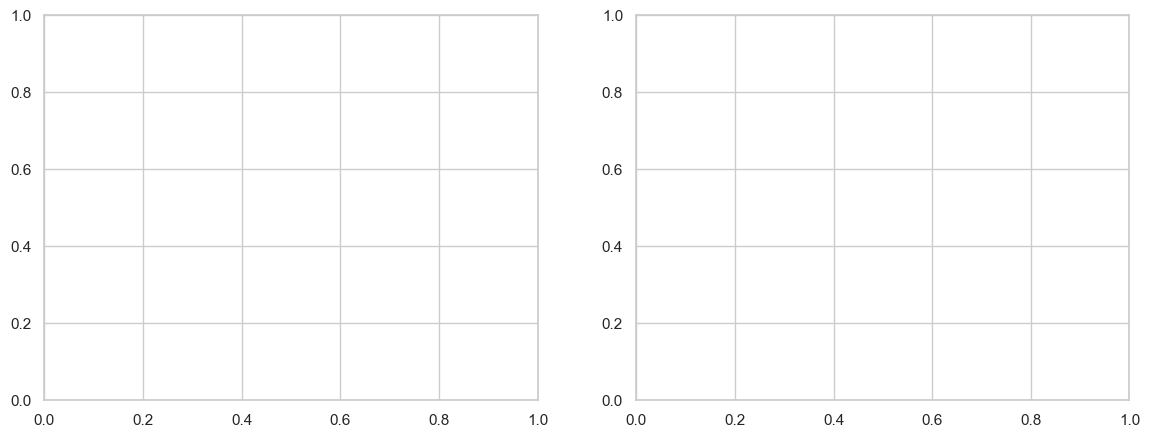

In [14]:
#model evaluation
print("Performance Evaluation")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [15]:
# Confusion Matrix Layout
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

Text(0.5, 1.0, 'Confusion Matrix')

In [16]:
# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(
    fpr, tpr, color="crimson", lw=2, label=f"ROC Curve (AUC = {auc_score:.2f})"
)
axes[1].plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [17]:
#features importance analysis

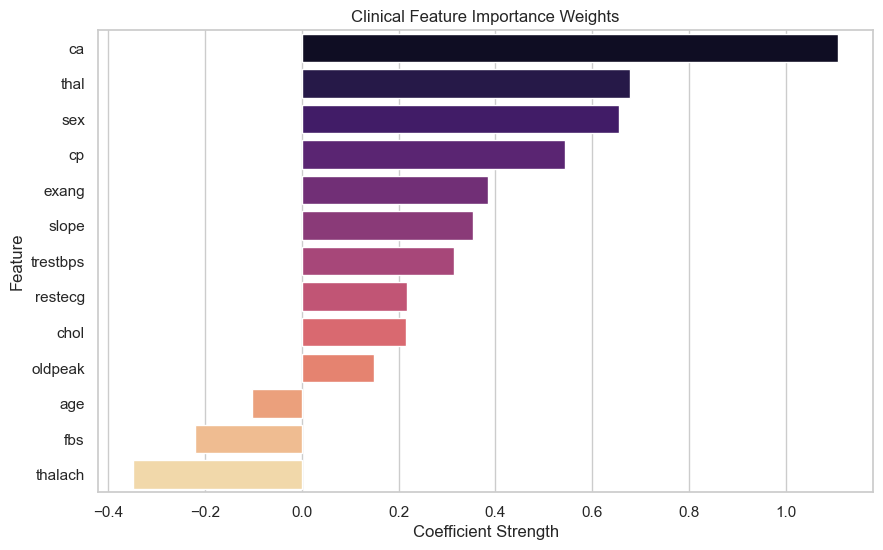

### Ordered Feature Weights ###
 Feature  Importance (Weight)
      ca             1.107898
    thal             0.677821
     sex             0.655563
      cp             0.543483
   exang             0.383642
   slope             0.354072
trestbps             0.313655
 restecg             0.217329
    chol             0.215375
 oldpeak             0.149953
     age            -0.103159
     fbs            -0.220560
 thalach            -0.348486


In [18]:
coefficients = model.coef_[0]
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance (Weight)": coefficients}
).sort_values(by="Importance (Weight)", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance (Weight)",
    y="Feature",
    data=feature_importance,
    palette="magma",
    hue="Feature",
    legend=False,
)
plt.title("Clinical Feature Importance Weights")
plt.xlabel("Coefficient Strength")
plt.show()

print("### Ordered Feature Weights ###")
print(feature_importance.to_string(index=False))